In [1]:
include("evolMPDO.jl");

In [2]:
include("IsingED.jl");

In [12]:
using PyPlot

In [3]:
N = 8;
h = 1.0;
psiMPS = Ising_GS_DMRG(N,h,false,nsweeps=10);

After sweep 1 energy=-9.612598602423347  maxlinkdim=16 maxerr=8.23E-07 time=21.588
After sweep 2 energy=-9.829702237024684  maxlinkdim=15 maxerr=1.95E-08 time=0.008
After sweep 3 energy=-9.83794779160682  maxlinkdim=11 maxerr=3.11E-09 time=0.007
After sweep 4 energy=-9.83795144604059  maxlinkdim=6 maxerr=3.24E-09 time=0.007
After sweep 5 energy=-9.837951446199034  maxlinkdim=6 maxerr=3.24E-09 time=0.007
After sweep 6 energy=-9.837951446199057  maxlinkdim=6 maxerr=6.91E-11 time=0.244
After sweep 7 energy=-9.83795144619905  maxlinkdim=6 maxerr=6.91E-11 time=0.006
After sweep 8 energy=-9.837951446199046  maxlinkdim=6 maxerr=6.91E-11 time=0.006
After sweep 9 energy=-9.837951446199058  maxlinkdim=6 maxerr=6.91E-11 time=0.006
After sweep 10 energy=-9.837951446199048  maxlinkdim=6 maxerr=6.91E-11 time=0.016


In [4]:
M_GS = myMPS(MPS_to_array(psiMPS));

In [5]:
p1 = 0.2;
p2 = 0.4; # Get the two noisy states
Ws1 = Array{Float64,3}[purified_dephasing_channel(p1,[0,0,1]) for _ in 1:N]
M1 = add_noise_MPS(M_GS, Ws1)

Ws2 = Array{Float64,3}[purified_dephasing_channel(p2,[0,0,1]) for _ in 1:N]
M2 = add_noise_MPS(M_GS, Ws2);

In [18]:
M1dense = MPDO_to_dense(M1);
M2dense = MPDO_to_dense(M2);

rho1dense = M1dense*M1dense'
rho2dense = M2dense*M2dense'
F0 = compute_fidelity(rho1dense,rho2dense)

0.9714929136468069

In [7]:
compute_overlap(M1,M2)  ## fidelity of purification without optimization

0.9223681599999985

In [44]:
M2_new, ovs = optimize_overlap_onefloor(M1,M2,[diagm(ones(4)) for _ in 1:2*N-3]);

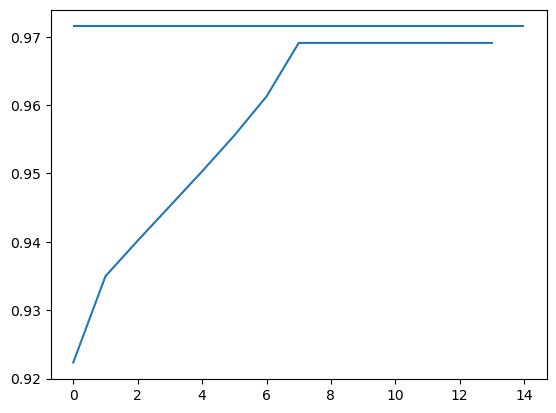

PyObject <matplotlib.collections.LineCollection object at 0x00000202491E6280>

In [45]:
plot(ovs)
hlines(y=F0,xmin=0, xmax = length(ovs))

In [46]:
ovs

14-element Vector{Float64}:
 0.9223681599999997
 0.934980787511734
 0.940177382665139
 0.9452360978007549
 0.9503121355190457
 0.9555537490664839
 0.9612681728572593
 0.9690889804984155
 0.9690895785561867
 0.9690898292160279
 0.9690900385714871
 0.9690902409936744
 0.9690904662595016
 0.9690908571189552

In [66]:
dt = 0.2;
Us = Matrix[]
for i in 1:2*N-3
    H = randn(4,4) + 1im*randn(4,4)
    H = (H+H')/2
    push!(Us, exp(im*dt*H))
end

In [67]:
M2_new, ovs = optimize_overlap_onefloor(complex(M1),complex(M2),Us);

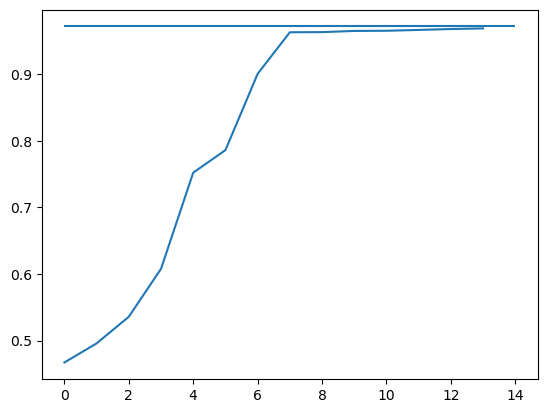

PyObject <matplotlib.collections.LineCollection object at 0x00000202566EAF70>

In [68]:
plot(ovs)
hlines(y=F0,xmin=0, xmax = length(ovs))

In [69]:
ovs

14-element Vector{Float64}:
 0.4671026037414021
 0.49575714613066796
 0.5357599097102309
 0.6077211301579465
 0.7520727124605237
 0.7858867301652385
 0.9003612722637732
 0.962819469666468
 0.9630052724788112
 0.9647991048504696
 0.965061968735808
 0.9663019962051975
 0.9676859152496483
 0.968595975710442

In [65]:
function optimize_overlap_onefloor(M1::myMPDO,M2::myMPDO,Us::Vector{<:Matrix};truncation = true, max_bd = 1024, max_err=1E-10)
    ## Act a sequential circuit on M1 and maximize |<M2|M1>|
    ## Us = initial guess of the unitary network. 
    ## Us order: U_{12}, U_{23}, ... U{n-1,n} U_{n-2,n-1} ... U_{12} 
    ## one floor: length(Us) = 2N-3 (k-floor length(Us) = k*(2N-4) + 1) 
    ## Assumes that M1 and M2 are right-canonical ** important **
    ## note - unitaries are acted on M2 (ancilla leg) - and we will return the modified M2 in right canonical form
    N = length(M1)
    @assert length(Us) == 2*N-3  ## This is one-floor constraint
    
    ov_opts = Float64[] #optimized fidelity after applying each optimization
    
    ## 1. precontract the tensor network from M1 and save all intermidates
    M1_interms = myMPDO[]
    push!(M1_interms, M1);
    M1cp = copy(M1)
    for i in 1:N-1
        U = Us[i]
        site = i;
        ~, M1_out = unitary_evol_two_site_ancilla(M1cp, U, site, "l"; truncation = truncation, max_bd = max_bd, max_err = max_err)
        push!(M1_interms, M1_out)
        M1cp = copy(M1_out)
    end
    for i in N:2*N-3
        site = 2*N-i-2
        U = Us[i]
        ~, M1_out = unitary_evol_two_site_ancilla(M1cp, U, site, "r"; truncation = truncation, max_bd = max_bd, max_err = max_err)
        push!(M1_interms, M1_out)
        M1cp = copy(M1_out) 
    end
    
    ## 2. Left to right sweep - from U12 to U_{n-1,n} (reverse order of Us)
    M1cp = M1_interms[end-1]
    M2_interms = myMPDO[]
    M2cp = copy(M2)
    push!(M2_interms, M2cp)
    l_env = diagm(ones(1))
    r_envs = right_environments(M1cp,M2cp) ## Right canonical form assumed for M1  ## This will NOT change during the sweep 
    push!(ov_opts,abs(tr(r_envs[end]))) ## Initial Us overlap
    for i in 1:N-1
        r_env = r_envs[N-i] ## right enviroment
        
        A1 = M1cp.TensorList[i]
        A2 = M1cp.TensorList[i+1]
        
        B1 = M2cp.TensorList[i]
        B2 = M2cp.TensorList[i+1]
        
        @tensor U_env[a1,a2,a1p,a2p] := l_env[b1,t1] * A1[t1,s,a1,t2] * conj(B1)[b1,s,a1p,b2] * A2[t2,ss,a2,t3] * r_env[t3,b3] *conj(B2)[b2,ss,a2p,b3]
        d1,d2,d1p,d2p = size(U_env)
        U_env = reshape(U_env,(d1*d2,d1p*d2p))
        U = nothing; S=nothing; V=nothing;
        try
            U,S,V = svd(U_env,alg=LinearAlgebra.DivideAndConquer())
        catch
            U,S,V = svd(U_env,alg=LinearAlgebra.QRIteration())
        end
        U_opt = V*U'
        ov = sum(S)
        push!(ov_opts,ov) ## This is the optimized overlap
        
        ~, M2cp = unitary_evol_two_site_ancilla(M2cp, Matrix(U_opt'), i, "l"; truncation = truncation, max_bd = max_bd, max_err = max_err)
        #ov = abs(compute_overlap(M1_interms[end-i],M2cp))
        #@show ov
        push!(M2_interms, M2cp)
        if(i<N-1)
            M1cp = M1_interms[end-i-1]
            l_env = apply_TM_l(M1cp.TensorList[i],M2cp.TensorList[i],l_env)
        end
    end
    
    #println("Switch!!")
    
    ## 3. Right to left sweep from U_{n-2,n-1} to U_{1,2} (reverse order of Us)
    ~,M2cp = canonicalize_right_one_site(M2cp, N)
    M1cp = M1_interms[N-2]
    l_envs = left_environments(M1cp,M2cp)
    r_env = diagm(ones(1))
    r_env = apply_TM_r(M1cp.TensorList[N],M2cp.TensorList[N],r_env)
    for i in N-2:-1:1
        l_env = l_envs[i]
        A1 = M1cp.TensorList[i]
        A2 = M1cp.TensorList[i+1]
        
        B1 = M2cp.TensorList[i]
        B2 = M2cp.TensorList[i+1]  
        @tensor U_env[a1,a2,a1p,a2p] := l_env[b1,t1] * A1[t1,s,a1,t2] * conj(B1)[b1,s,a1p,b2] * A2[t2,ss,a2,t3] * r_env[t3,b3] *conj(B2)[b2,ss,a2p,b3]
        d1,d2,d1p,d2p = size(U_env)
        U_env = reshape(U_env,(d1*d2,d1p*d2p))
        U = nothing; S=nothing; V=nothing;
        try
            U,S,V = svd(U_env,alg=LinearAlgebra.DivideAndConquer())
        catch
            U,S,V = svd(U_env,alg=LinearAlgebra.QRIteration())
        end
        U_opt = V*U'
        ov = sum(S)
        push!(ov_opts,ov) ## This is the optimized overlap
        
        ~, M2cp = unitary_evol_two_site_ancilla(M2cp, Matrix(U_opt'), i, "r"; truncation = truncation, max_bd = max_bd, max_err = max_err)
        
        #ov = abs(compute_overlap(M1_interms[i],M2cp))
       # @show ov
        push!(M2_interms, M2cp)
        if(i>1)
            M1cp = M1_interms[i-1]
            r_env = apply_TM_r(M1cp.TensorList[i+1],M2cp.TensorList[i+1],r_env)
        end
    end
    return M2cp, ov_opts
end

optimize_overlap_onefloor (generic function with 1 method)